In [1]:
import pandas as pd
filepath = "/data/nishome/xuhaochen/Time-Series-Library/dataset/ETT-small/ETTh1.csv"
df_raw = pd.read_csv(filepath)
df_raw

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
...,...,...,...,...,...,...,...,...
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904000
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044000
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271000
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778000


In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. 加载数据
filepath = "/data/nishome/xuhaochen/Time-Series-Library/dataset/ETT-small/ETTh1.csv"
df_raw = pd.read_csv(filepath)

# 2. 设置与原始类一致的参数 (假设是多变量任务 'M')
features = 'M' 
target = 'OT'
# 这里的 seq_len 会影响验证集和测试集的起始点，但计算全局 scale 时主要看训练集 border
seq_len = 96 

# 3. 提取特征列 (跳过第一列 date)
if features == 'M' or features == 'MS':
    cols_data = df_raw.columns[1:]
    df_data = df_raw[cols_data]
elif features == 'S':
    df_data = df_raw[[target]]

# 4. 定义训练集边界 (完全对齐原代码逻辑)
# border1s[0] = 0, border2s[0] = 12 * 30 * 24
train_start = 0
train_end = 12 * 30 * 24 

# 5. 执行归一化逻辑并提取参数
scaler = StandardScaler()
train_data = df_data.iloc[train_start:train_end]

# 只在训练集上 fit
scaler.fit(train_data.values)

# 6. 输出每一列的均值和标准差
feature_names = df_data.columns
means = scaler.mean_
stds = scaler.scale_

print("根据训练集计算出的各特征统计量：")
stats_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean (μ)': means,
    'Std (σ)': stds
})
print(stats_df)

# 如果你想看 Feature 7 (OT) 的具体数值
ot_mean = scaler.mean_[-1]
ot_std = scaler.scale_[-1]
print(f"\n油温 (OT) 的均值: {ot_mean:.4f}, 标准差: {ot_std:.4f}")

根据训练集计算出的各特征统计量：
  Feature   Mean (μ)   Std (σ)
0    HUFL   7.937742  5.812749
1    HULL   2.021039  2.090105
2    MUFL   5.079771  5.518794
3    MULL   0.746186  1.926379
4    LUFL   2.781762  1.023523
5    LULL   0.788453  0.630237
6      OT  17.128262  9.176491

油温 (OT) 的均值: 17.1283, 标准差: 9.1765


In [38]:
scaler.mean_

array([ 7.93774225,  2.02103866,  5.0797706 ,  0.74618588,  2.78176239,
        0.78845312, 17.1282617 ])

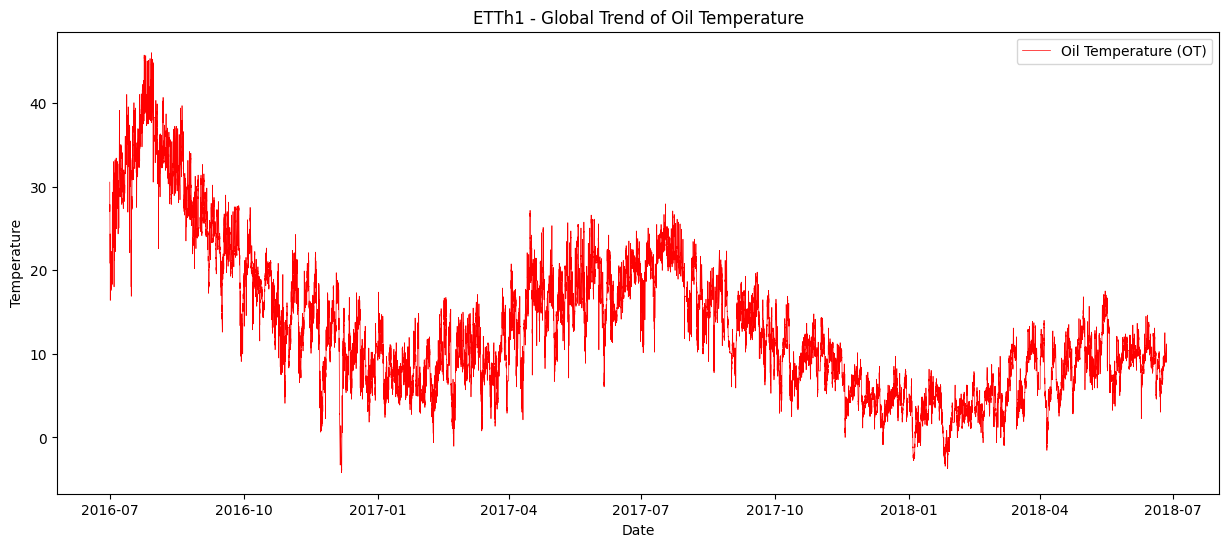

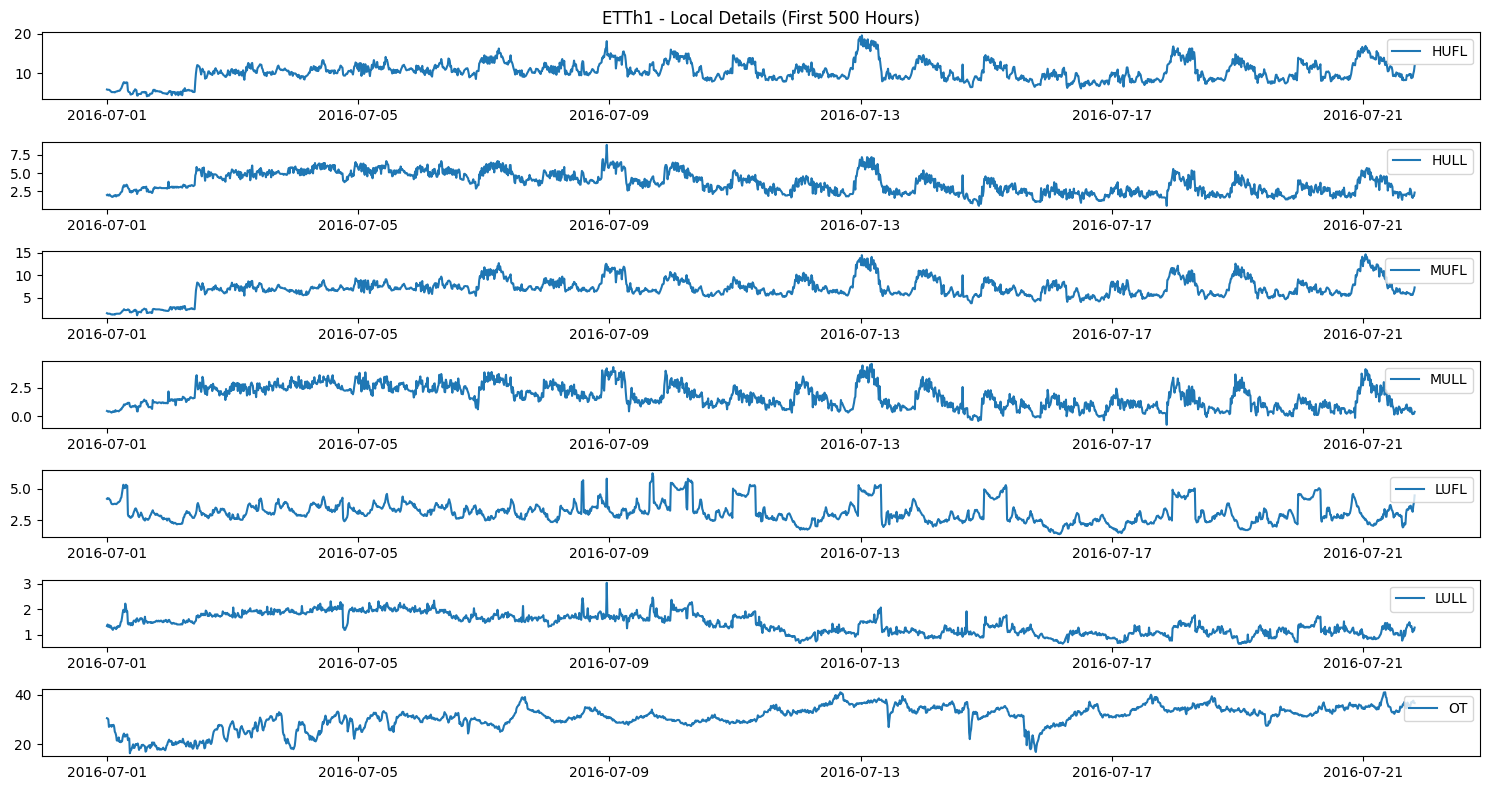

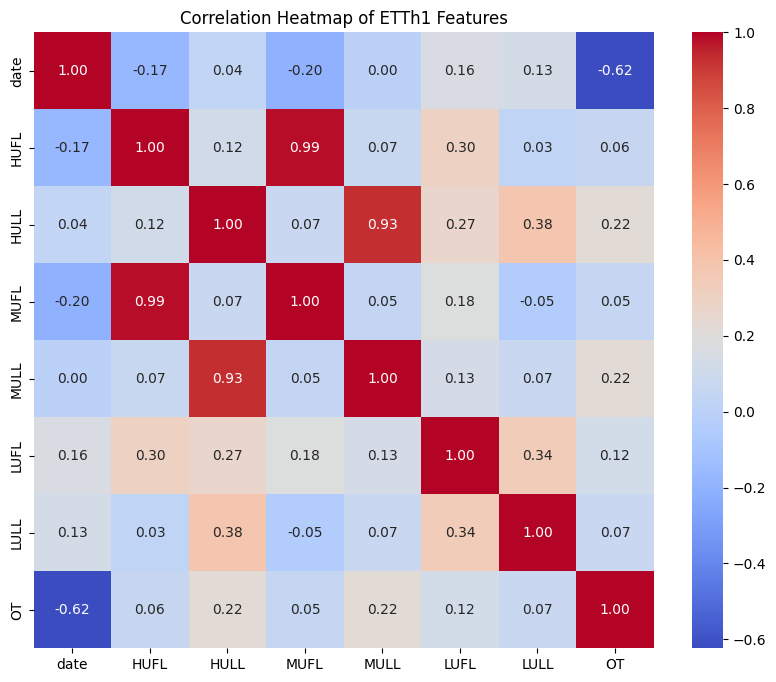

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
filepath = "/data/nishome/xuhaochen/Time-Series-Library/dataset/ETT-small/ETTm1.csv"
df_raw = pd.read_csv(filepath)

# 确保 date 列是时间格式
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 2. 全局趋势可视化 (所有变量)
# 为了防止数据太密集，可以观察 OT 变量的整体走势
plt.figure(figsize=(15, 6))
plt.plot(df_raw['date'], df_raw['OT'], label='Oil Temperature (OT)', color='red', linewidth=0.5)
plt.title('ETTh1 - Global Trend of Oil Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# 3. 局部细节可视化 (展示前 500 小时，观察周期性)
# 这是你之前提到的“趋势项”和“季节项”最明显的地方
cols_to_show = ['HUFL', 'HULL','MUFL','MULL','LUFL','LULL','OT'] # 选取几个代表性变量
df_subset = df_raw.iloc[:2000]

plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_show):
    plt.subplot(len(cols_to_show), 1, i+1)
    plt.plot(df_subset['date'], df_subset[col], label=col)
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('ETTh1 - Local Details (First 500 Hours)')
plt.tight_layout()
plt.show()

# 4. 变量相关性热力图
# 看看负荷变量与油温之间的强弱关系
plt.figure(figsize=(10, 8))
sns.heatmap(df_raw.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of ETTh1 Features')
plt.show()

In [2]:
import numpy as np
import os

# 定义文件夹路径
folder_path = '/data/nishome/xuhaochen/Time-Series-Library/results/long_term_forecast_ETTh1_96_192_DLinear_ETTh1_ftM_sl96_ll48_pl192_dm512_nh8_el2_dl1_df2048_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0'
folder_path = '/data/nishome/xuhaochen/Time-Series-Library/results/long_term_forecast_ETTh1_96_720_iTransformer_ETTh1_ftM_sl96_ll48_pl720_dm128_nh8_el2_dl1_df128_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0'
# 读取 npy 文件
preds = np.load(os.path.join(folder_path, 'pred.npy'))
trues = np.load(os.path.join(folder_path, 'true.npy'))
metrics = np.load(os.path.join(folder_path, 'metrics.npy'))

# 打印信息确认
print(f"预测值 (preds) 维度: {preds.shape}")   # 通常是 [样本数, 预测长度, 变量数]
print(f"真实值 (trues) 维度: {trues.shape}")   # 维度应与 preds 一致
print(f"评价指标 (metrics): {metrics}")        # 通常包含 [MAE, MSE, RMSE, MAPE, MSPE]

预测值 (preds) 维度: (2161, 720, 7)
真实值 (trues) 维度: (2161, 720, 7)
评价指标 (metrics): [5.0410324e-01 5.2151906e-01 7.2216278e-01 1.1191704e+01 4.9497312e+04]


In [ ]:
b = 2

def visual(true, preds=None, name='./pic/test.pdf'):
    """
    Results visualization
    """
    plt.figure()
    if preds is not None:
        plt.plot(preds, label='Prediction', linewidth=2)
    plt.plot(true, label='GroundTruth', linewidth=2)
    plt.legend()
    # plt.savefig(name, bbox_inches='tight')
for i in range(7):
    pred = preds[b,:,i]
    true = trues[b,:,i]
    visual(true, pred)
    print(metric(true, pred))


In [3]:
def MAE(pred, true):
    return np.mean(np.abs(true - pred))
def MSE(pred, true):
    return np.mean((true - pred) ** 2)
def RMSE(pred, true):
    return np.sqrt(MSE(pred, true))
def MAPE(pred, true):
    return np.mean(np.abs((true - pred) / true))
def MSPE(pred, true):
    return np.mean(np.square((true - pred) / true))
def metric(pred, true):
    mae = MAE(pred, true)
    mse = MSE(pred, true)
    rmse = RMSE(pred, true)
    mape = MAPE(pred, true)
    mspe = MSPE(pred, true)
    return mae, mse, rmse, mape, mspe

In [9]:
metric(preds[:,:336,:],trues[:,:336,:])

(np.float32(0.46157458),
 np.float32(0.4685167),
 np.float32(0.6844828),
 np.float32(9.360345),
 np.float32(41696.824))

In [4]:
for i in range(7):
    print(i)
    print(metric(preds[:,:96,i],trues[:,:96,i]))

0
(np.float32(0.62492603), np.float32(0.7911584), np.float32(0.8894708), np.float32(2.483962), np.float32(169.64818))
1
(np.float32(0.36101213), np.float32(0.24040312), np.float32(0.4903092), np.float32(1.9464012), np.float32(58.982506))
2
(np.float32(0.6308963), np.float32(0.8272178), np.float32(0.90951514), np.float32(6.242151), np.float32(7625.636))
3
(np.float32(0.33107078), np.float32(0.20936878), np.float32(0.45756835), np.float32(45.26006), np.float32(309381.84))
4
(np.float32(0.53312266), np.float32(0.5792195), np.float32(0.7610647), np.float32(2.081178), np.float32(50.602306))
5
(np.float32(0.2858828), np.float32(0.13838458), np.float32(0.37200078), np.float32(1.6227618), np.float32(50.20184))
6
(np.float32(0.18043856), np.float32(0.053926572), np.float32(0.23222096), np.float32(0.15110531), np.float32(0.040470257))


In [1]:
import torch

# 1. 设置路径
checkpoint_path = '/data/nishome/xuhaochen/Time-Series-Library/checkpoints/long_term_forecast_ETTh1_96_48_Koopa_z_ETTh1_ftM_sl96_ll48_pl48_dm512_nh8_el2_dl1_df2048_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0/checkpoint.pth'

# 2. 加载 checkpoint
# 注意：如果是从 GPU 训练的要在 CPU 查看，请加上 map_location='cpu'
state_dict = torch.load(checkpoint_path, map_location='cpu')

# 3. 查找并打印所有包含 'sigma' 的键值对
print("--- 阻尼/增长系数 sigma 学习结果 ---")
found = False
for key, value in state_dict.items():
    if 'sigma' in key:
        print(f"层路径: {key}")
        print(f"数值 (sigma): {value.item():.6f}")
        
        # 物理意义解读
        if value.item() < 0:
            print("→ 物理表现：阻尼态 (信号随时间衰减)")
        elif value.item() > 0:
            print("→ 物理表现：受激态 (信号随时间增强)")
        else:
            print("→ 物理表现：稳态 (等幅振荡)")
        print("-" * 30)
        found = True

if not found:
    print("未在 checkpoint 中找到名为 'sigma' 的参数，请检查代码中是否已正确定义为 nn.Parameter 并保存。")

--- 阻尼/增长系数 sigma 学习结果 ---
层路径: time_inv_kps.0.sigma
数值 (sigma): -0.038975
→ 物理表现：阻尼态 (信号随时间衰减)
------------------------------
层路径: time_inv_kps.1.sigma
数值 (sigma): -0.038035
→ 物理表现：阻尼态 (信号随时间衰减)
------------------------------
层路径: time_inv_kps.2.sigma
数值 (sigma): -0.035659
→ 物理表现：阻尼态 (信号随时间衰减)
------------------------------


/tmp/ipykernel_390739/1725632123.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location='cpu')
